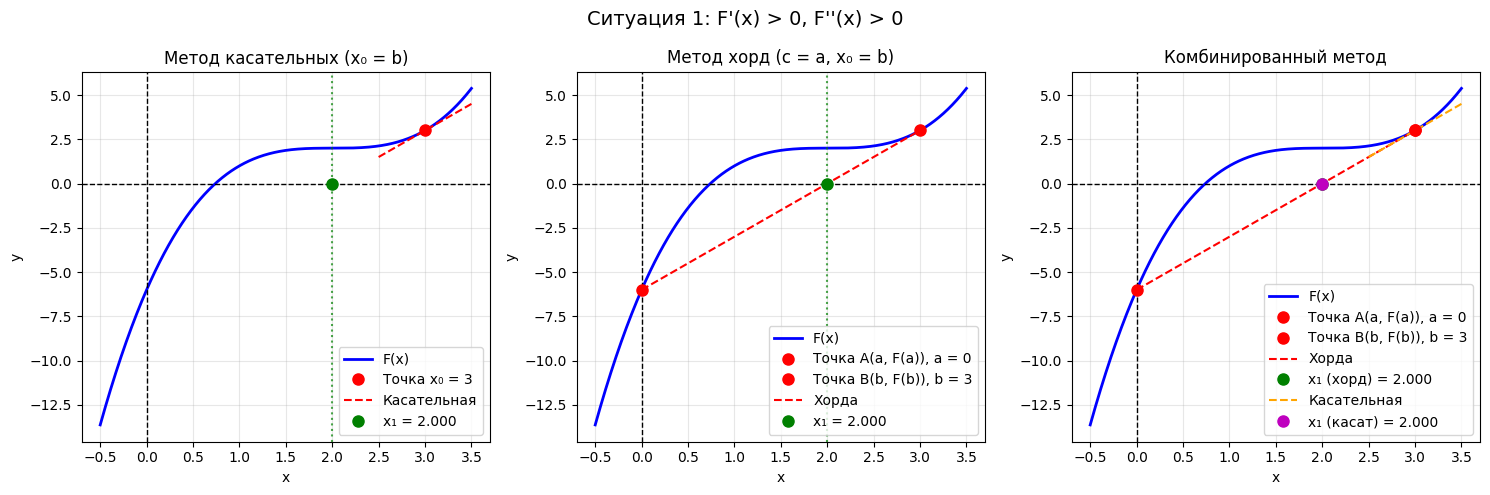

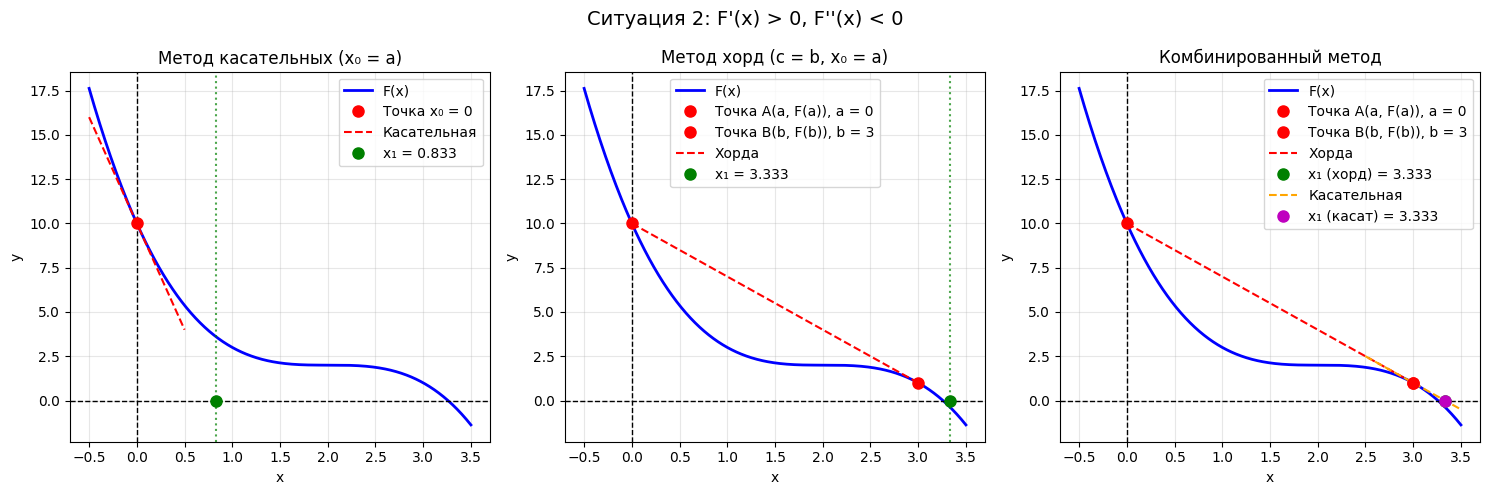

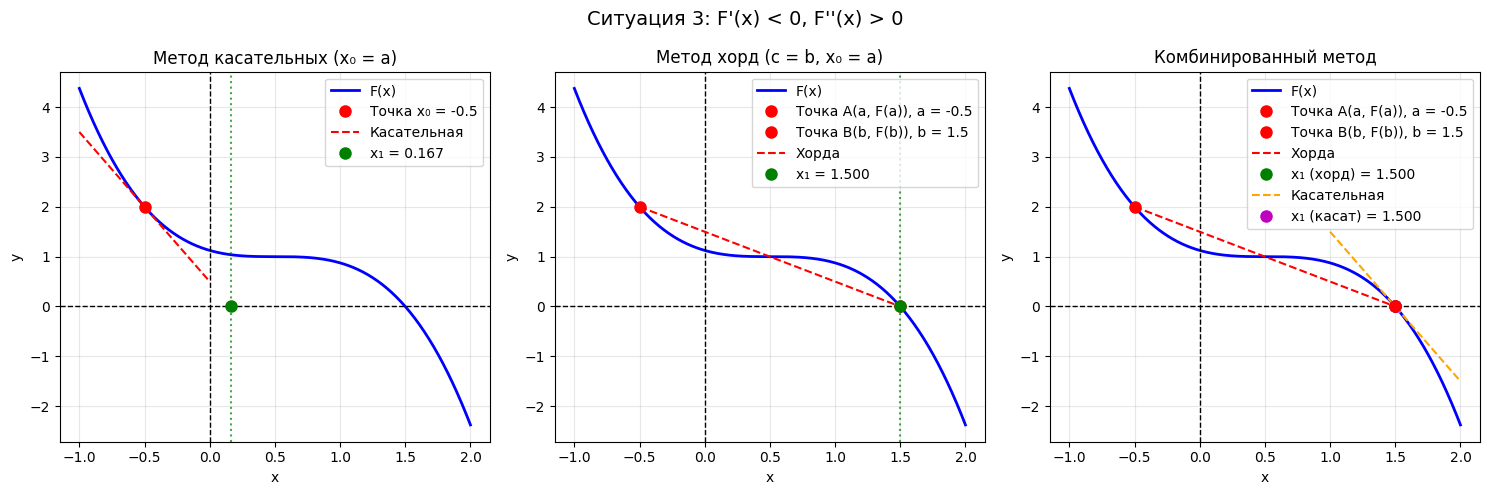

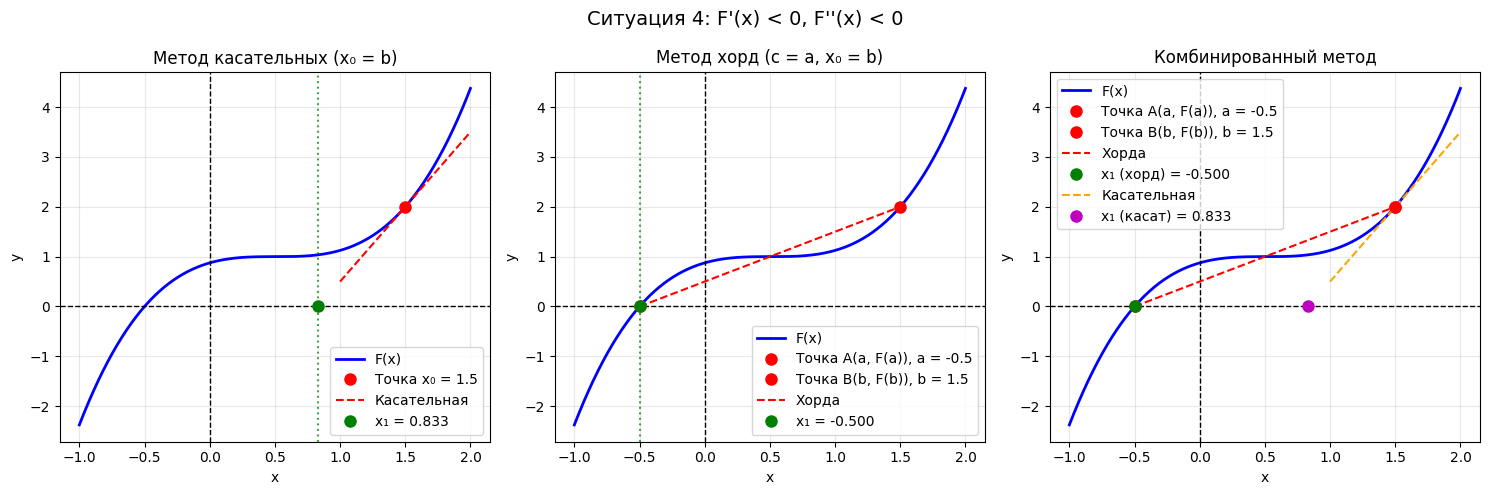

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Функция для примера (ситуация 1: F'(x) > 0, F''(x) > 0)
def f1(x):
    return (x - 2)**3 + 2  # возрастающая, выпуклая вниз

def f1_prime(x):
    return 3 * (x - 2)**2

# Функция для примера (ситуация 2: F'(x) > 0, F''(x) < 0)
def f2(x):
    return - (x - 2)**3 + 2  # возрастающая, выпуклая вверх

def f2_prime(x):
    return -3 * (x - 2)**2

# Функция для примера (ситуация 3: F'(x) < 0, F''(x) > 0)
def f3(x):
    return - (x - 0.5)**3 + 1  # убывающая, выпуклая вниз

def f3_prime(x):
    return -3 * (x - 0.5)**2

# Функция для примера (ситуация 4: F'(x) < 0, F''(x) < 0)
def f4(x):
    return (x - 0.5)**3 + 1  # убывающая, выпуклая вверх

def f4_prime(x):
    return 3 * (x - 0.5)**2

# Метод касательных: найти точку пересечения касательной с осью x
def tangent_intersection(f, f_prime, x0):
    """Возвращает точку пересечения касательной в точке x0 с осью x"""
    return x0 - f(x0) / f_prime(x0)

# Метод хорд: найти точку пересечения хорды с осью x
def chord_intersection(f, a, b):
    """Возвращает точку пересечения хорды между (a, f(a)) и (b, f(b)) с осью x"""
    return a - f(a) * (b - a) / (f(b) - f(a))

# Построение графика с методом касательных
def plot_tangent_method(f, f_prime, a, b, x0, title, ax):
    x_vals = np.linspace(a - 0.5, b + 0.5, 500)
    y_vals = f(x_vals)
    
    ax.plot(x_vals, y_vals, 'b-', linewidth=2, label='F(x)')
    ax.axhline(y=0, color='k', linestyle='--', linewidth=1)
    ax.axvline(x=0, color='k', linestyle='--', linewidth=1)
    ax.grid(True, alpha=0.3)
    
    # Точка на графике
    ax.plot(x0, f(x0), 'ro', markersize=8, label=f'Точка x₀ = {x0}')
    
    # Касательная
    x_tangent = np.linspace(x0 - 0.5, x0 + 0.5, 100)
    y_tangent = f(x0) + f_prime(x0) * (x_tangent - x0)
    ax.plot(x_tangent, y_tangent, 'r--', linewidth=1.5, label='Касательная')
    
    # Точка пересечения касательной с осью x
    x1 = tangent_intersection(f, f_prime, x0)
    ax.plot(x1, 0, 'go', markersize=8, label=f'x₁ = {x1:.3f}')
    ax.axvline(x=x1, color='g', linestyle=':', alpha=0.7)
    
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()

# Построение графика с методом хорд
def plot_chord_method(f, a, b, title, ax):
    x_vals = np.linspace(a - 0.5, b + 0.5, 500)
    y_vals = f(x_vals)
    
    ax.plot(x_vals, y_vals, 'b-', linewidth=2, label='F(x)')
    ax.axhline(y=0, color='k', linestyle='--', linewidth=1)
    ax.axvline(x=0, color='k', linestyle='--', linewidth=1)
    ax.grid(True, alpha=0.3)
    
    # Концы отрезка
    ax.plot(a, f(a), 'ro', markersize=8, label=f'Точка A(a, F(a)), a = {a}')
    ax.plot(b, f(b), 'ro', markersize=8, label=f'Точка B(b, F(b)), b = {b}')
    
    # Хорда
    x_chord = np.linspace(a, b, 100)
    y_chord = f(a) + (f(b) - f(a)) * (x_chord - a) / (b - a)
    ax.plot(x_chord, y_chord, 'r--', linewidth=1.5, label='Хорда')
    
    # Точка пересечения хорды с осью x
    x1 = chord_intersection(f, a, b)
    ax.plot(x1, 0, 'go', markersize=8, label=f'x₁ = {x1:.3f}')
    ax.axvline(x=x1, color='g', linestyle=':', alpha=0.7)
    
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()

# Построение графика комбинированного метода
def plot_combined_method(f, f_prime, a, b, title, ax):
    x_vals = np.linspace(a - 0.5, b + 0.5, 500)
    y_vals = f(x_vals)
    
    ax.plot(x_vals, y_vals, 'b-', linewidth=2, label='F(x)')
    ax.axhline(y=0, color='k', linestyle='--', linewidth=1)
    ax.axvline(x=0, color='k', linestyle='--', linewidth=1)
    ax.grid(True, alpha=0.3)
    
    # Метод хорд (слева)
    x_chord = chord_intersection(f, a, b)
    ax.plot(a, f(a), 'ro', markersize=8, label=f'Точка A(a, F(a)), a = {a}')
    ax.plot(b, f(b), 'ro', markersize=8, label=f'Точка B(b, F(b)), b = {b}')
    
    x_chord_line = np.linspace(a, b, 100)
    y_chord_line = f(a) + (f(b) - f(a)) * (x_chord_line - a) / (b - a)
    ax.plot(x_chord_line, y_chord_line, 'r--', linewidth=1.5, label='Хорда')
    ax.plot(x_chord, 0, 'go', markersize=8, label=f'x₁ (хорд) = {x_chord:.3f}')
    
    # Метод касательных (справа)
    x_tangent = tangent_intersection(f, f_prime, b)
    x_tan_line = np.linspace(b - 0.5, b + 0.5, 100)
    y_tan_line = f(b) + f_prime(b) * (x_tan_line - b)
    ax.plot(x_tan_line, y_tan_line, 'orange', linestyle='--', linewidth=1.5, label='Касательная')
    ax.plot(x_tangent, 0, 'mo', markersize=8, label=f'x₁ (касат) = {x_tangent:.3f}')
    ax.plot(b, f(b), 'ro', markersize=8)
    
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()

# ============================================================
# ПОСТРОЕНИЕ ГРАФИКОВ ДЛЯ ВСЕХ ЧЕТЫРЁХ СИТУАЦИЙ
# ============================================================

# Ситуация 1: F'(x) > 0, F''(x) > 0
fig1, axes = plt.subplots(1, 3, figsize=(15, 5))
fig1.suptitle('Ситуация 1: F\'(x) > 0, F\'\'(x) > 0', fontsize=14)

plot_tangent_method(f1, f1_prime, 0, 3, 3, 
                    'Метод касательных (x₀ = b)', axes[0])
plot_chord_method(f1, 0, 3, 
                  'Метод хорд (c = a, x₀ = b)', axes[1])
plot_combined_method(f1, f1_prime, 0, 3, 
                     'Комбинированный метод', axes[2])

plt.tight_layout()
plt.show()

# Ситуация 2: F'(x) > 0, F''(x) < 0
fig2, axes = plt.subplots(1, 3, figsize=(15, 5))
fig2.suptitle('Ситуация 2: F\'(x) > 0, F\'\'(x) < 0', fontsize=14)

plot_tangent_method(f2, f2_prime, 0, 3, 0, 
                    'Метод касательных (x₀ = a)', axes[0])
plot_chord_method(f2, 0, 3, 
                  'Метод хорд (c = b, x₀ = a)', axes[1])
plot_combined_method(f2, f2_prime, 0, 3, 
                     'Комбинированный метод', axes[2])

plt.tight_layout()
plt.show()

# Ситуация 3: F'(x) < 0, F''(x) > 0
fig3, axes = plt.subplots(1, 3, figsize=(15, 5))
fig3.suptitle('Ситуация 3: F\'(x) < 0, F\'\'(x) > 0', fontsize=14)

plot_tangent_method(f3, f3_prime, -0.5, 1.5, -0.5, 
                    'Метод касательных (x₀ = a)', axes[0])
plot_chord_method(f3, -0.5, 1.5, 
                  'Метод хорд (c = b, x₀ = a)', axes[1])
plot_combined_method(f3, f3_prime, -0.5, 1.5, 
                     'Комбинированный метод', axes[2])

plt.tight_layout()
plt.show()

# Ситуация 4: F'(x) < 0, F''(x) < 0
fig4, axes = plt.subplots(1, 3, figsize=(15, 5))
fig4.suptitle('Ситуация 4: F\'(x) < 0, F\'\'(x) < 0', fontsize=14)

plot_tangent_method(f4, f4_prime, -0.5, 1.5, 1.5, 
                    'Метод касательных (x₀ = b)', axes[0])
plot_chord_method(f4, -0.5, 1.5, 
                  'Метод хорд (c = a, x₀ = b)', axes[1])
plot_combined_method(f4, f4_prime, -0.5, 1.5, 
                     'Комбинированный метод', axes[2])

plt.tight_layout()
plt.show()